In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
# LOADING DATASET
df = pd.read_csv('/Users/yasir/Desktop/statistics-python-mastery/04_distributions/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [41]:
'''
Test 1 — One Sample T-Test
Business question: The industry benchmark for credit score is 650. Is the average credit score of borrowers in this dataset significantly different from 650?
Write the code to:
1-Calculate the mean credit score from the data
2-Run a one-sample t-test using scipy.stats.ttest_1samp
3-Print the t-statistic, p-value, and your conclusion — is the mean significantly different from 650 or not?
'''
# ================================================================================
# Problem 1
print("PROBLEM 1")
print(f'Average credit score is: {df['CreditScore'].mean():.0f}')
print(" " * 40)

# ================================================================================
# Problem 2
print("=" * 40)
print("PROBLEM 2")
pop_avg = 650
t_test_value,p_value = stats.ttest_1samp(df['CreditScore'], pop_avg)
print(f'T test statistics: {t_test_value:.2f}\nP value: {p_value:.2e}')  
print(" " * 40)

# ================================================================================
# Problem 3
print("=" * 40)
print("PROBLEM 3")
if p_value <= 0.05:
    print(f"P value is {p_value:.2e}, so we reject the null hypothesis; there is enough evidence the average credit score is not 650.")
else:
     print(f"P value is {p_value:.2e}, so we fail to  reject the null hypothesis; there is not enough evidence the average credit score is not 650.") 

PROBLEM 1
Average credit score is: 574
                                        
PROBLEM 2
T test statistics: -240.84
P value: 0.00e+00
                                        
PROBLEM 3
P value is 0.00e+00, so we reject the null hypothesis; there is enough evidence the average credit score is not 650.


In [65]:
'''
Test 2 — Two Sample T-Test
Business question: Do defaulters and non-defaulters have significantly different average incomes? Or is the income difference just random noise?
Write the code to:

1-Split the dataset into two groups — defaulters (Default==1) and non-defaulters (Default==0)
2-Calculate mean income for each group
3-Run a two-sample t-test using scipy.stats.ttest_ind
4-Print the t-statistic, p-value, and your business conclusion
'''

default_df = df[df['Default'] == 1]
non_default_df = df[df['Default'] == 0]

# Hypothesis
H0 = "Same avg income"
H1 = "Differnce avg income"

# Problem 1 & 2 — means
print(f"Mean income (Defaulters): {default_df['Income'].mean():,.0f}")
print(f"Mean income (Non-Defaulters): {non_default_df['Income'].mean():,.0f}")

# Problem 3 — two-sample t-test
t_test_value, p_value = stats.ttest_ind(default_df['Income'], non_default_df['Income'])
print(f'T test statistic: {t_test_value:.2f}')
print(f'P value: {p_value:.2e}')

# Problem 4 — conclusion
if p_value <= 0.05:
    print(f"P value is {p_value:.2e}, so we reject the null hypothesis; there is enough evidence that defaulters and non-defaulters have significantly different average incomes.")
else:
    print(f"P value is {p_value:.2e}, so we fail to reject the null hypothesis; there is not enough evidence that incomes differ between the two groups.")


Mean income (Defaulters): 71,845
Mean income (Non-Defaulters): 83,899
T test statistic: -50.33
P value: 0.00e+00
P value is 0.00e+00, so we reject the null hypothesis; there is enough evidence that defaulters and non-defaulters have significantly different average incomes.


CONTINGENCY TABLE
Default         Default  Non Default
EmploymentType                      
Full-time          6024        57632
Part-time          7677        56484
Self-employed      7302        56404
Unemployed         8650        55174
                                        
CHI-SQUARE TEST
Chi-square test ran successfully.
EVALUATION AND INTERPRETATION
Chi-square statistic: 529.74
P value: 1.71e-114
Degrees of freedom: 3
Expected frequencies:
[[ 7392.25981899 56263.74018101]
 [ 7450.90458474 56710.09541526]
 [ 7398.06623144 56307.93376856]
 [ 7411.76936483 56412.23063517]]
P value is 1.71e-114, so we reject the null hypothesis; there is enough evidence that EmploymentType and Default are related.


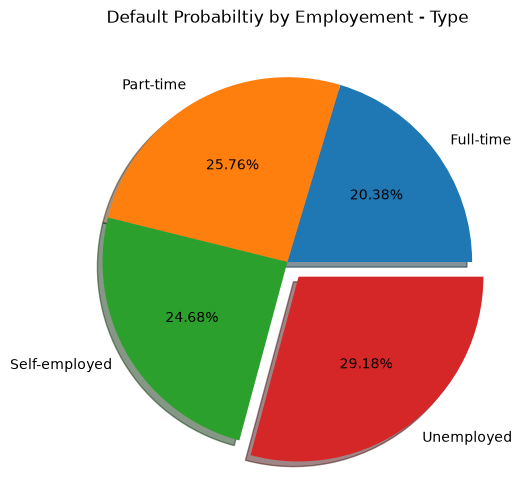

In [125]:
'''
Test 3 — Chi-Square Test
Business question: Is there a relationship between EmploymentType and Default? Or are they independent — meaning employment type has no bearing on whether someone defaults?
Write the code to:

1-Build a contingency table (crosstab) of EmploymentType vs Default using pd.crosstab
2-Run a chi-square test using scipy.stats.chi2_contingency
3-Print the chi-square statistic, p-value, and your business conclusion
4-As a comment — which employment type do you think will have the highest default rate, and why?
'''

# Problem 1
print("=" * 40)
print("CONTINGENCY TABLE")
contingency_table = pd.crosstab(df['EmploymentType'], df['Default'].map({0:"Non Default", 1:"Default"}))
print(contingency_table)
print(" "* 40)

# Problem 2
print("=" * 40)
print("CHI-SQUARE TEST")

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test ran successfully.")
   

# Problem 3
print("=" * 40)
print("EVALUATION AND INTERPRETATION")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"P value: {p_value:.2e}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

if p_value <= 0.05:
    print(f"P value is {p_value:.2e}, so we reject the null hypothesis; there is enough evidence that EmploymentType and Default are related.")
else:
    print(f"P value is {p_value:.2e}, so we fail to reject the null hypothesis; there is not enough evidence that EmploymentType and Default are related.")


# Problem 4
default_rate = contingency_table['Default'] / contingency_table.sum(axis=1)

plt.figure(figsize=(6,6))
default_rate.plot(
    kind='pie', labels=default_rate.index,
    autopct = "%.2f%%",
    explode = (0,0,0,0.1),
    shadow = True
    )
plt.title("Default Probabiltiy by Employement - Type")    
plt.show()
# Unemployed borrowers have the highest default rate (~29.18%), likely because they lack a stable income source to reliably repay loans.